# 5. Burnout Risk Analysis

This section identifies employees with potential burnout risk based on overtime, work-life balance, engagement, workload, and travel-related factors.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load updated dataset

df = pd.read_csv("../data/processed/employee_engagement_dataset.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Engagement_Index,Engagement_Category
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,8,0,1,6,4,0,5,2.50,Moderate
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1,10,3,3,10,7,1,7,2.75,Moderate
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,7,3,3,0,0,0,0,2.75,Moderate
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,8,3,3,8,7,3,0,3.25,High
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,1,6,3,3,2,2,2,2,2.50,Moderate


In [3]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 33


In [4]:
# Check burnout-related variables

print("OverTime values:")
print(df["OverTime"].unique())

print("\nWorkLifeBalance values:")
print(sorted(df["WorkLifeBalance"].unique()))

OverTime values:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

WorkLifeBalance values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [5]:
# Create Burnout Risk Score

df["Burnout_Risk_Score"] = (
    (df["OverTime"] == "Yes").astype(int)
    + (df["WorkLifeBalance"] <= 2).astype(int)
)

df["Burnout_Risk_Score"].value_counts().sort_index()

Burnout_Risk_Score
0    756
1    588
2    126
Name: count, dtype: int64

In [6]:
# Create Burnout Risk Level

def burnout_risk_level(score):
    if score == 2:
        return "High"
    elif score == 1:
        return "Medium"
    else:
        return "Low"

df["Burnout_Risk_Level"] = df["Burnout_Risk_Score"].apply(
    burnout_risk_level
)

df["Burnout_Risk_Level"].value_counts()

Burnout_Risk_Level
Low       756
Medium    588
High      126
Name: count, dtype: int64

In [7]:
# Calculate burnout risk percentage

burnout_percentage = (
    df["Burnout_Risk_Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

burnout_percentage

Burnout_Risk_Level
Low       51.43
Medium    40.00
High       8.57
Name: proportion, dtype: float64

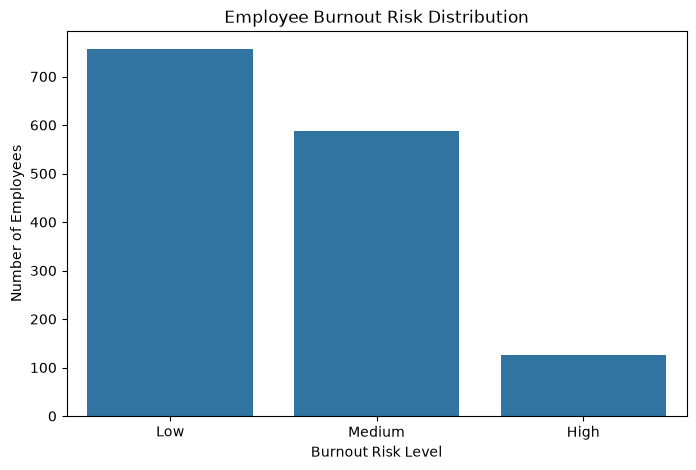

In [8]:
# Plot burnout risk distribution

risk_counts = df["Burnout_Risk_Level"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Employee Burnout Risk Distribution")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Number of Employees")
plt.show()

In [9]:
# Analyze overtime and burnout risk

overtime_burnout = pd.crosstab(
    df["OverTime"],
    df["Burnout_Risk_Level"]
)

overtime_burnout

Burnout_Risk_Level,High,Low,Medium
OverTime,,,
No,0,756,298
Yes,126,0,290


In [10]:
# Analyze work-life balance and burnout risk

wlb_burnout = pd.crosstab(
    df["WorkLifeBalance"],
    df["Burnout_Risk_Level"]
)

wlb_burnout

Burnout_Risk_Level,High,Low,Medium
WorkLifeBalance,,,
1,22,0,58
2,104,0,240
3,0,639,254
4,0,117,36


In [11]:
# Analyze overtime and work-life balance

overtime_wlb = pd.crosstab(
    df["WorkLifeBalance"],
    df["OverTime"]
)

overtime_wlb

OverTime,No,Yes
WorkLifeBalance,,
1,58,22
2,240,104
3,639,254
4,117,36


In [12]:
# Calculate burnout risk by department

department_burnout = pd.crosstab(
    df["Department"],
    df["Burnout_Risk_Level"],
    normalize="index"
).mul(100).round(2)

department_burnout

Burnout_Risk_Level,High,Low,Medium
Department,,,
Human Resources,3.17,58.73,38.10
Research & Development,8.84,49.95,41.21
Sales,8.74,53.59,37.67


In [13]:
# Identify high-risk employees by department

high_risk_department = (
    df[df["Burnout_Risk_Level"] == "High"]
    ["Department"]
    .value_counts()
)

high_risk_department

Department
Research & Development    85
Sales                     39
Human Resources            2
Name: count, dtype: int64

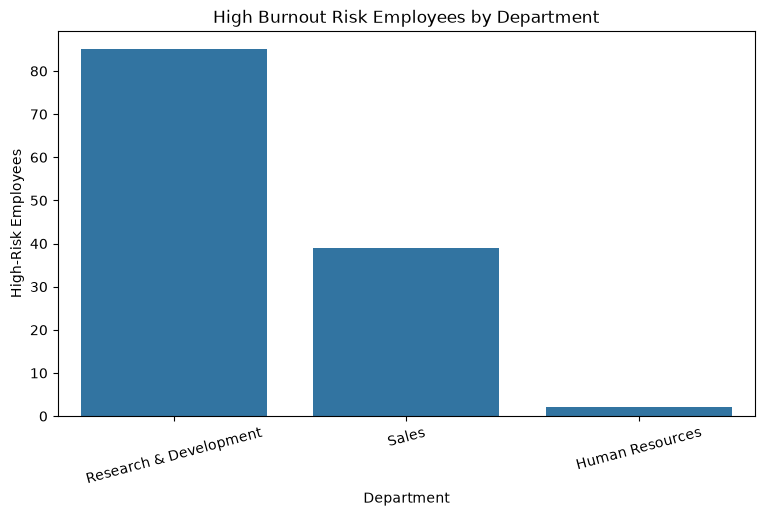

In [14]:
# Plot high burnout risk by department

plt.figure(figsize=(9, 5))

sns.barplot(
    x=high_risk_department.index,
    y=high_risk_department.values
)

plt.title("High Burnout Risk Employees by Department")
plt.xlabel("Department")
plt.ylabel("High-Risk Employees")
plt.xticks(rotation=15)
plt.show()

In [15]:
# Calculate burnout risk by job role

role_burnout = pd.crosstab(
    df["JobRole"],
    df["Burnout_Risk_Level"],
    normalize="index"
).mul(100).round(2)

role_burnout

Burnout_Risk_Level,High,Low,Medium
JobRole,,,
Healthcare Representative,6.11,47.33,46.56
Human Resources,3.85,59.62,36.54
Laboratory Technician,9.27,55.21,35.52
Manager,6.86,51.96,41.18
Manufacturing Director,7.59,52.41,40.00
Research Director,8.75,56.25,35.00
Research Scientist,10.96,42.81,46.23
Sales Executive,8.90,53.07,38.04
Sales Representative,7.23,57.83,34.94


In [16]:
# Identify high-risk employees by job role

high_risk_roles = (
    df[df["Burnout_Risk_Level"] == "High"]
    ["JobRole"]
    .value_counts()
)

high_risk_roles

JobRole
Research Scientist           32
Sales Executive              29
Laboratory Technician        24
Manufacturing Director       11
Healthcare Representative     8
Research Director             7
Manager                       7
Sales Representative          6
Human Resources               2
Name: count, dtype: int64

In [17]:
# Analyze business travel and burnout risk

travel_burnout = pd.crosstab(
    df["BusinessTravel"],
    df["Burnout_Risk_Level"],
    normalize="index"
).mul(100).round(2)

travel_burnout


Burnout_Risk_Level,High,Low,Medium
BusinessTravel,,,
Non-Travel,6.67,53.33,40.00
Travel_Frequently,7.94,48.38,43.68
Travel_Rarely,9.01,51.97,39.02


In [18]:
# Compare distance from home across burnout risk levels

distance_burnout = (
    df.groupby("Burnout_Risk_Level")["DistanceFromHome"]
    .mean()
    .round(2)
)

distance_burnout

Burnout_Risk_Level
High      9.60
Low       8.99
Medium    9.36
Name: DistanceFromHome, dtype: float64

In [19]:
# Compare burnout risk with engagement

burnout_engagement = (
    df.groupby("Burnout_Risk_Level")["Engagement_Index"]
    .mean()
    .round(2)
)

burnout_engagement

Burnout_Risk_Level
High      2.80
Low       2.70
Medium    2.74
Name: Engagement_Index, dtype: float64

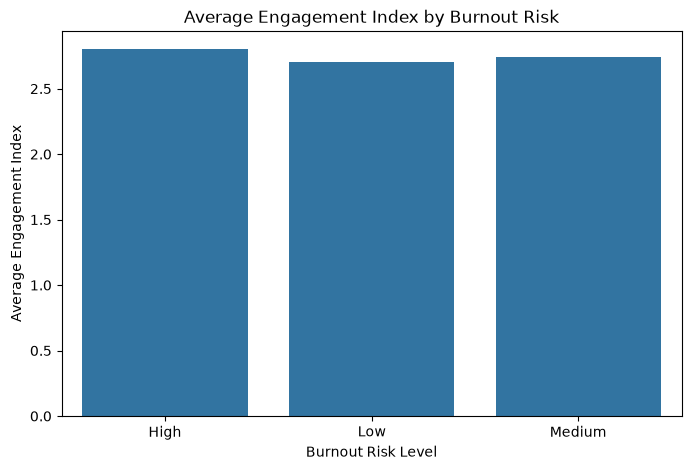

In [20]:
# Plot burnout risk against engagement

plt.figure(figsize=(8, 5))

sns.barplot(
    x=burnout_engagement.index,
    y=burnout_engagement.values
)

plt.title("Average Engagement Index by Burnout Risk")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Average Engagement Index")
plt.show()

In [21]:
# Count high-risk employees

high_risk_count = (
    df["Burnout_Risk_Level"] == "High"
).sum()

print("High Burnout Risk Employees:", high_risk_count)

High Burnout Risk Employees: 126


In [22]:
# Display high-risk employee profile

high_risk_employees = df[
    df["Burnout_Risk_Level"] == "High"
][
    [
        "Age",
        "Department",
        "JobRole",
        "OverTime",
        "WorkLifeBalance",
        "Engagement_Index",
        "Engagement_Category",
        "BusinessTravel",
        "DistanceFromHome",
        "YearsAtCompany",
        "Attrition"
    ]
]

high_risk_employees.head(10)

,Age,Department,JobRole,OverTime,WorkLifeBalance,Engagement_Index,Engagement_Category,BusinessTravel,DistanceFromHome,YearsAtCompany,Attrition
0,41,Sales,Sales Executive,Yes,1,2.50,Moderate,Travel_Rarely,1,6,1
6,59,Research & Development,Laboratory Technician,Yes,2,2.25,Moderate,Travel_Rarely,3,1,0
16,32,Research & Development,Research Scientist,Yes,2,2.75,Moderate,Travel_Rarely,5,6,0
17,22,Research & Development,Laboratory Technician,Yes,2,3.50,High,Non-Travel,16,1,0
34,24,Research & Development,Research Scientist,Yes,2,2.50,Moderate,Travel_Rarely,1,2,1
51,28,Research & Development,Laboratory Technician,Yes,2,3.00,High,Travel_Rarely,5,2,1
52,44,Sales,Sales Executive,Yes,2,2.25,Moderate,Travel_Rarely,1,4,0
54,26,Sales,Sales Executive,Yes,2,3.00,High,Travel_Rarely,23,2,0
62,50,Research & Development,Research Director,Yes,2,2.75,Moderate,Travel_Rarely,7,27,0
69,36,Research & Development,Research Scientist,Yes,2,2.50,Moderate,Travel_Rarely,9,1,1


In [23]:
# Identify employees with high burnout risk and low engagement

priority_employees = df[
    (df["Burnout_Risk_Level"] == "High") &
    (df["Engagement_Category"] == "Low")
]

print("Priority Intervention Employees:", len(priority_employees))

Priority Intervention Employees: 5


In [24]:
# Save dataset with burnout risk features

output_path = "../data/processed/employee_engagement_dataset.csv"

df.to_csv(output_path, index=False)

print("Dataset updated successfully.")
print("File:", output_path)

Dataset updated successfully.
File: ../data/processed/employee_engagement_dataset.csv


## Observation

Burnout risk was assessed using overtime and work-life balance indicators. Employees were classified into Low, Medium, and High burnout-risk levels based on the number of risk factors present.

The analysis provides visibility into high-risk employee groups across departments, job roles, travel patterns, workload, and engagement levels. Employees showing both high burnout risk and low engagement represent priority areas for preventive HR intervention.